In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler

In [101]:
df = pd.read_csv('data/klike_challenge_dataset.csv')

In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   campaign_id          500 non-null    str    
 1   date                 500 non-null    str    
 2   platform             500 non-null    str    
 3   category             500 non-null    str    
 4   objective            500 non-null    str    
 5   target_audience_age  500 non-null    str    
 6   is_retargeting       500 non-null    bool   
 7   video_duration_s     461 non-null    float64
 8   format               500 non-null    str    
 9   has_subtitle         454 non-null    object 
 10  has_cta              500 non-null    bool   
 11  has_hook             500 non-null    bool   
 12  has_face             500 non-null    bool   
 13  text_density         500 non-null    str    
 14  music_voice_ratio    462 non-null    float64
 15  impressions          500 non-null    int64  
 16  c

In [103]:
df.describe()

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,5.000000e+02,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,1.537385e+05,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.171736e+06,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,1.000000e+03,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.986000e+03,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,2.324100e+04,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,5.517275e+04,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,1.405276e+07,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


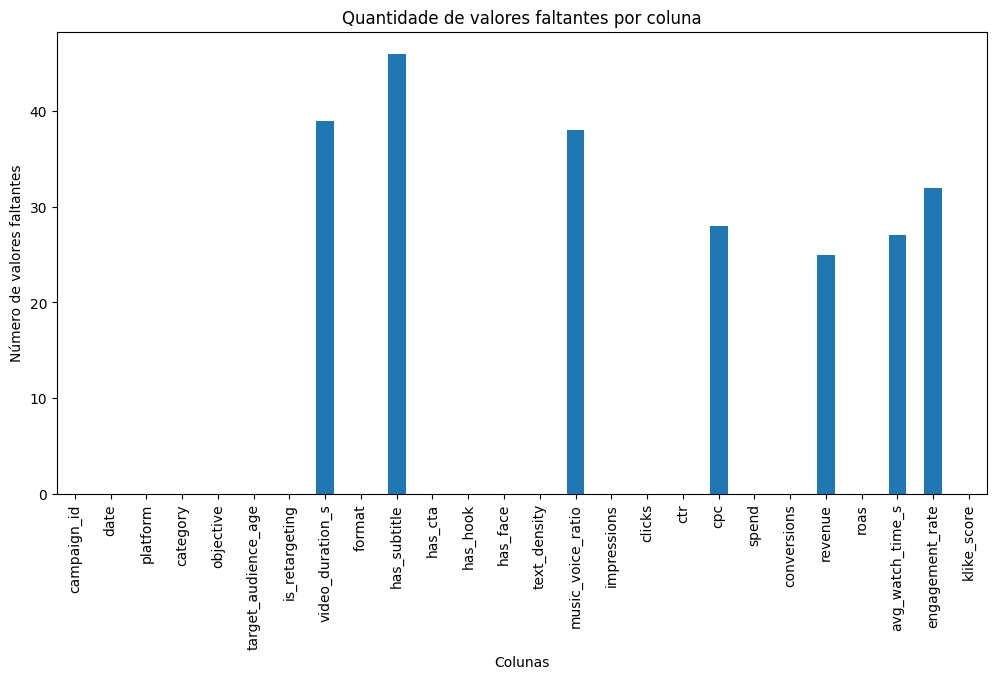

In [104]:
missing_counts = df.isna().sum()

# Plot
plt.figure(figsize=(12,6))
missing_counts.plot(kind='bar')
plt.title("Quantidade de valores faltantes por coluna")
plt.ylabel("Número de valores faltantes")
plt.xlabel("Colunas")
plt.show()

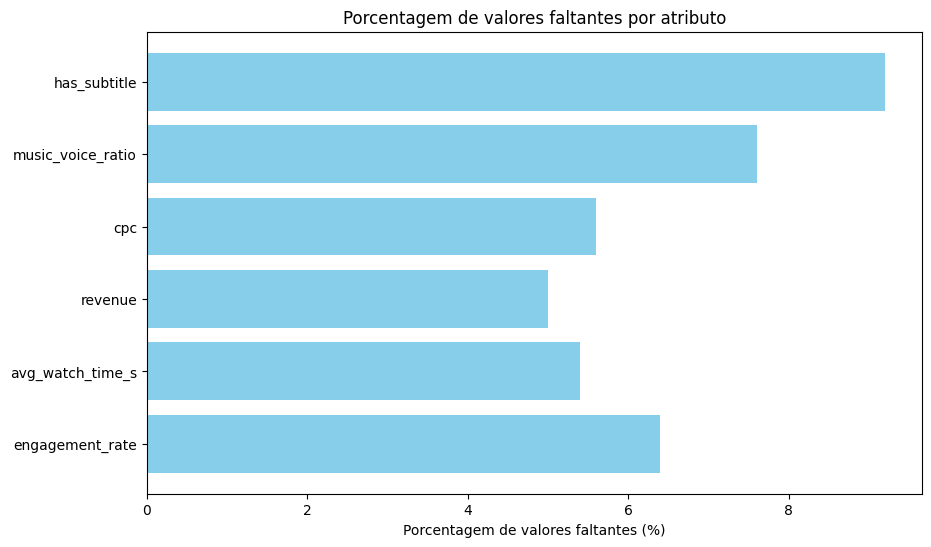

In [107]:
# Lista das colunas e porcentagens
cols = ['has_subtitle', 'music_voice_ratio', 'cpc', 'revenue', 'avg_watch_time_s', 'engagement_rate']
percentages = [9.2, 7.6, 5.6, 5.0, 5.4, 6.4]

plt.figure(figsize=(10,6))
plt.barh(cols, percentages, color='skyblue')
plt.xlabel("Porcentagem de valores faltantes (%)")
plt.title("Porcentagem de valores faltantes por atributo")
plt.gca().invert_yaxis()  # para mostrar do maior para o menor
plt.show()

In [105]:
# Porcentagem de valores faltantes
missing_percent = df.isna().mean() * 100

# Exibir
print(missing_percent)

campaign_id            0.0
date                   0.0
platform               0.0
category               0.0
objective              0.0
target_audience_age    0.0
is_retargeting         0.0
video_duration_s       7.8
format                 0.0
has_subtitle           9.2
has_cta                0.0
has_hook               0.0
has_face               0.0
text_density           0.0
music_voice_ratio      7.6
impressions            0.0
clicks                 0.0
ctr                    0.0
cpc                    5.6
spend                  0.0
conversions            0.0
revenue                5.0
roas                   0.0
avg_watch_time_s       5.4
engagement_rate        6.4
klike_score            0.0
dtype: float64


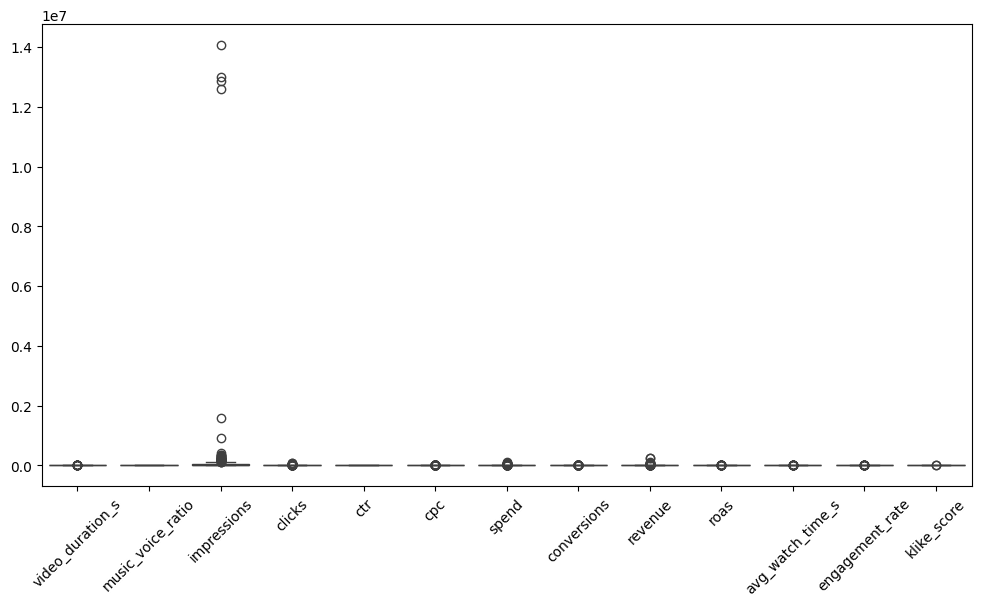

In [111]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

Colunas com maior diferença de magnitude: ['impressions', 'revenue', 'spend', 'clicks', 'conversions', 'video_duration_s']


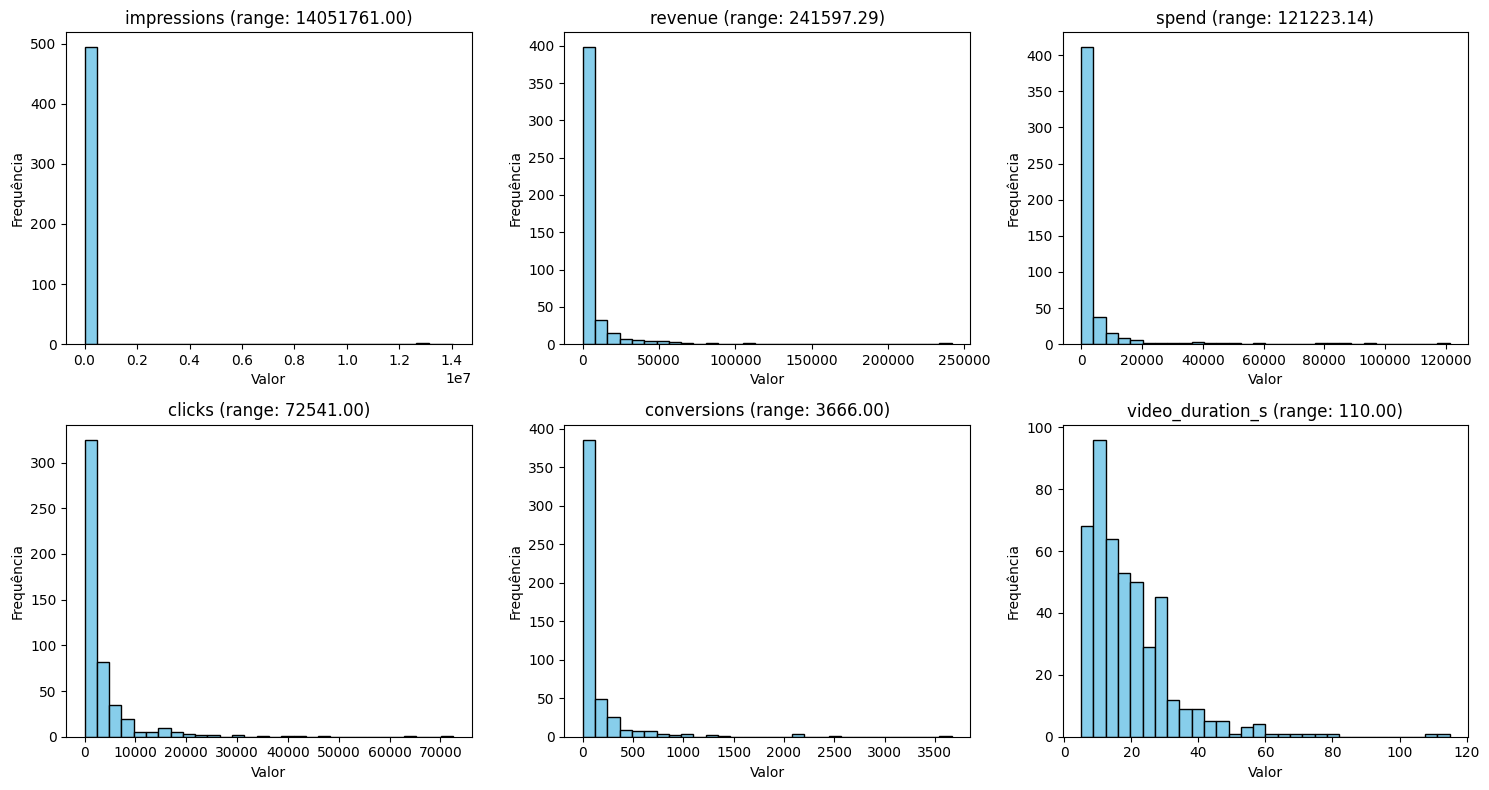

In [110]:
atributos = df.select_dtypes(include='number').columns

# Calcula a diferença entre máximo e mínimo
ranges = df[atributos].max() - df[atributos].min()

# Seleciona as top N colunas com maior diferença
top_n = 6
top_atributos = ranges.sort_values(ascending=False).head(top_n).index
print("Colunas com maior diferença de magnitude:", list(top_atributos))
n = len(top_atributos)
cols_subplot = 3
rows_subplot = math.ceil(n / cols_subplot)

plt.figure(figsize=(5*cols_subplot, 4*rows_subplot))
for i, col in enumerate(top_atributos, 1):
    plt.subplot(rows_subplot, cols_subplot, i)
    plt.hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    plt.title(f"{col} (range: {ranges[col]:.2f})")
    plt.xlabel("Valor")
    plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

In [112]:
df['impressions_lg'] = np.log1p(df['impressions'])
df['clicks_lg'] = np.log1p(df['clicks'])

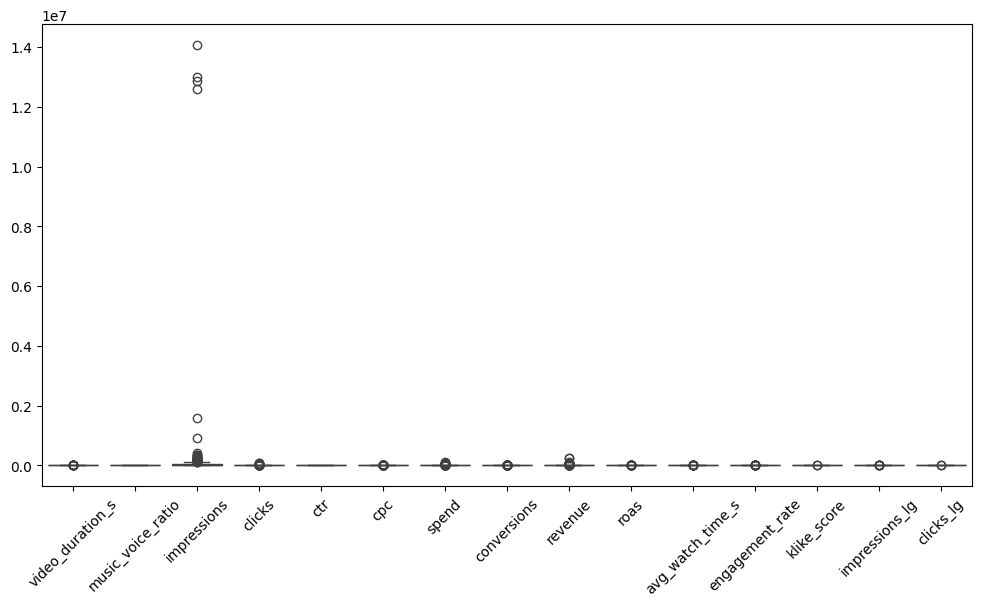

In [113]:
numeric_cols = df.select_dtypes(include='number').columns

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [114]:
scaler = MinMaxScaler()
df[['spend_norm','revenue_norm','conversions_norm']] = scaler.fit_transform(df[['spend','revenue','conversions']])

In [115]:
df['spend']

0       4823.24
1       1745.22
2       5726.22
3        426.71
4        894.90
         ...   
495       53.82
496      977.43
497    10145.28
498      235.20
499    14601.34
Name: spend, Length: 500, dtype: float64

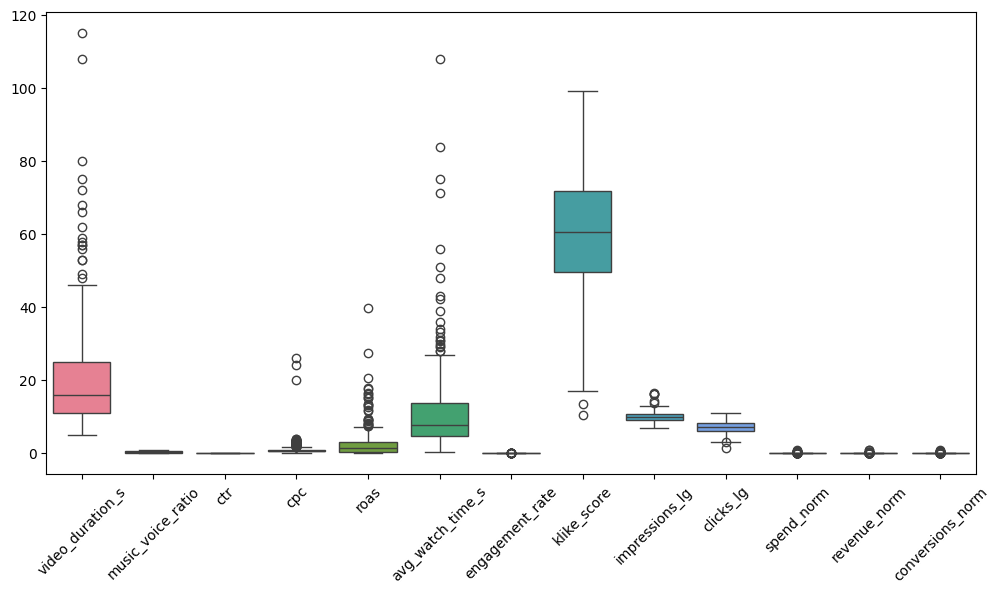

In [116]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [117]:
df['video_duration_s'].isna().sum()
# Preenche NaNs com a mediana da coluna
df['video_duration_s'] = df['video_duration_s'].fillna(df['video_duration_s'].mean())

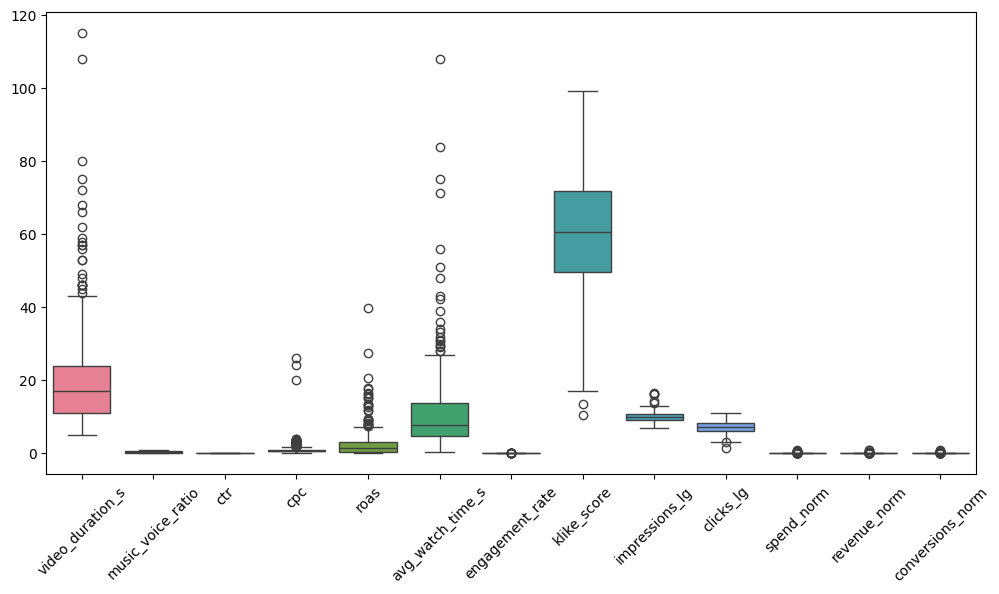

In [118]:
numeric_cols = df.select_dtypes(include='number').columns
numeric_cols = numeric_cols.drop(['spend','revenue','conversions','clicks','impressions'])
plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=45)  # se os nomes forem longos
plt.show()

In [31]:
df.describe()

,video_duration_s,music_voice_ratio,impressions,clicks,ctr,cpc,spend,conversions,revenue,roas,avg_watch_time_s,engagement_rate,klike_score
count,461.000000,462.000000,500.000000,500.000000,500.000000,472.000000,500.000000,500.0000,475.000000,500.000000,473.000000,468.000000,500.0000
mean,19.392625,0.399848,10.094230,3594.104000,0.070968,1.112903,4213.151620,131.3520,6367.936863,2.499000,10.664271,0.027952,60.1568
std,13.529351,0.202674,1.351120,7018.212512,0.045302,1.955625,11573.975576,314.5654,19267.180696,3.592365,10.533275,0.023057,15.5891
min,5.000000,0.020000,6.908755,4.000000,0.002200,0.050000,2.960000,0.0000,0.000000,0.000000,0.400000,0.001000,10.4000
25%,11.000000,0.230000,9.209038,461.750000,0.033200,0.530000,313.452500,10.0000,262.175000,0.430000,4.700000,0.011100,49.7750
50%,16.000000,0.385000,10.053713,1351.000000,0.062750,0.710000,1031.000000,34.5000,1201.050000,1.490000,7.700000,0.021400,60.5500
75%,25.000000,0.550000,10.918239,3583.250000,0.104800,1.020000,2867.952500,111.0000,4189.025000,3.250000,13.900000,0.038800,71.9250
max,115.000000,0.920000,16.458330,72545.000000,0.150000,26.050000,121226.100000,3666.0000,241597.290000,39.920000,108.000000,0.100000,99.1000


In [18]:
count = (df['music_voice_ratio'] >= 0.80).sum()
print(count)

14


In [ ]:
df.isnull().sum()

In [ ]:
df[df['has_subtitle'].isnull()]

In [11]:
# Qual % é nulo?
df['has_subtitle'].isnull().mean()

# Os nulos têm algum padrão? (ex: só em uma plataforma?)
df[df['has_subtitle'].isnull()]['platform'].value_counts()

platform
Meta        21
TikTok      16
LinkedIn     9
Name: count, dtype: int64

In [12]:
df['has_subtitle'] = df['has_subtitle'].fillna(False)